In [2]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [4]:
!pip -q install torch torchvision torchaudio matplotlib pillow

import os, glob, shutil, zipfile

zip_candidates = [p for p in os.listdir('/content') if p.lower().endswith('.zip')]
if zip_candidates:
    zip_path = max([os.path.join('/content', z) for z in zip_candidates], key=os.path.getmtime)
    print("Found ZIP:", zip_path)
    for d in ["sample_computer_vision"]:
        shutil.rmtree(f"/content/{d}", ignore_errors=True)
    !unzip -q -o "$zip_path" -d /content
else:
    print("No ZIP found in /content. If using Google Drive, mount it and set data_dir manually in Cell 2.")
candidates = []
for d in glob.glob("/content/**", recursive=True):
    if (os.path.isdir(os.path.join(d, "train")) and
        os.path.isdir(os.path.join(d, "val"))):
        candidates.append(d)

print("Found data_dir candidates:", candidates[:5])


Found ZIP: /content/sample_computer_vision.zip
Found data_dir candidates: ['/content/sample_computer_vision']


In [5]:
import os, glob

data_dir = None
for d in glob.glob("/content/**", recursive=True):
    if os.path.isdir(os.path.join(d, "train")) and os.path.isdir(os.path.join(d, "val")):
        data_dir = d
        break

print("data_dir:", data_dir)
assert data_dir and os.path.isdir(os.path.join(data_dir, "train")), "train/ 폴더를 찾지 못했습니다."
assert os.path.isdir(os.path.join(data_dir, "val")), "val/ 폴더를 찾지 못했습니다."


data_dir: /content/sample_computer_vision


Device: cuda
classes: ['cats', 'dogs']


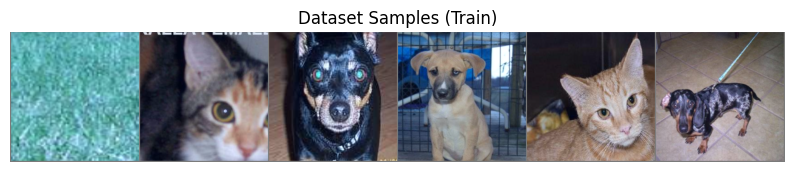

Epoch 1/3 | train | loss: 0.5890 | acc: 0.7445
Epoch 1/3 | val   | loss: 0.3824 | acc: 0.8550
Epoch 2/3 | train | loss: 0.3979 | acc: 0.8134
Epoch 2/3 | val   | loss: 0.9183 | acc: 0.6900
Epoch 3/3 | train | loss: 0.4221 | acc: 0.8094
Epoch 3/3 | val   | loss: 0.2496 | acc: 0.9200
Best val acc: 0.92


In [8]:
import torch, torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import torch.nn as nn, torch.optim as optim
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt
import numpy as np, time, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tfm = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
}

datasets_ = {x: datasets.ImageFolder(os.path.join(data_dir,x), tfm[x]) for x in ["train","val"]}
dataloaders = {x: DataLoader(datasets_[x], batch_size=16, shuffle=(x=="train")) for x in ["train","val"]}
class_names = datasets_["train"].classes
print("classes:", class_names)

# ① 데이터셋 시각화 (6장)
imgs, lbls = next(iter(dataloaders["train"]))
grid = torchvision.utils.make_grid(imgs[:6])
grid = grid.numpy().transpose((1,2,0))
grid = np.clip(grid*0.229+0.485, 0, 1)
plt.figure(figsize=(10,3))
plt.imshow(grid); plt.axis("off"); plt.title("Dataset Samples (Train)")
os.makedirs("/content/outputs", exist_ok=True)
plt.savefig("/content/outputs/dataset_samples.png", dpi=150)
plt.show()

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

EPOCHS = 3
log_lines = []
best_acc, best_w = 0.0, None
for epoch in range(EPOCHS):
    for phase in ["train","val"]:
        model.train() if phase=="train" else model.eval()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase=="train"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                preds = outputs.argmax(1)
                if phase=="train":
                    loss.backward(); optimizer.step()
            running_loss += loss.item()*inputs.size(0)
            running_corrects += torch.sum(preds==labels).item()

        epoch_loss = running_loss/len(datasets_[phase])
        epoch_acc  = running_corrects/len(datasets_[phase])
        line = f"Epoch {epoch+1}/{EPOCHS} | {phase:5s} | loss: {epoch_loss:.4f} | acc: {epoch_acc:.4f}"
        print(line); log_lines.append(line)

        if phase=="val" and epoch_acc > best_acc:
            best_acc, best_w = epoch_acc, model.state_dict()
    scheduler.step()

if best_w: model.load_state_dict(best_w)
torch.save(model.state_dict(), "/content/outputs/best_model.pth")

# 로그 저장
with open("/content/outputs/training_log.txt","w",encoding="utf-8") as f:
    f.write("\n".join(log_lines))
print("Best val acc:", best_acc)


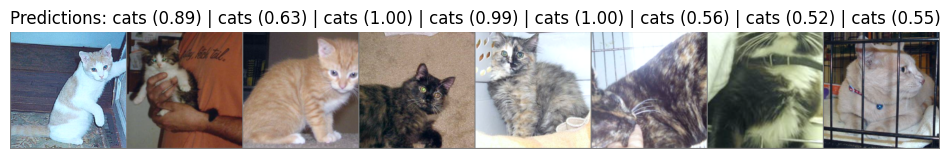

Saved files: ['training_log.txt', 'best_model.pth', 'preds_grid.png', 'dataset_samples.png']


In [7]:
import torch, torchvision, os, matplotlib.pyplot as plt
import numpy as np

model.eval()
imgs, lbls = next(iter(dataloaders["val"]))

with torch.no_grad():
    out   = model(imgs.to(device))
    probs = torch.softmax(out, dim=1).cpu()
    preds = probs.argmax(1)

show_n = max(6, min(8, len(imgs)))
grid = torchvision.utils.make_grid(imgs[:show_n])
grid = grid.numpy().transpose((1,2,0))
# denorm (ImageNet 통계)
grid = np.clip(grid*0.229+0.485, 0, 1)

titles = [f"{class_names[p.item()]} ({probs[i,p].item():.2f})"
          for i,p in enumerate(preds[:show_n])]

plt.figure(figsize=(12,4))
plt.imshow(grid); plt.axis("off")
plt.title("Predictions: " + " | ".join(titles))
os.makedirs("/content/outputs", exist_ok=True)
plt.savefig("/content/outputs/preds_grid.png", dpi=150)
plt.show()

print("Saved files:", os.listdir("/content/outputs"))